In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os


2025-08-19 09:56:10.151455: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755597370.383866      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755597370.448561      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
# Define paths
train_dir = "/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train"
test_dir  = "/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test"

# Define batch size and image size
batch_size = 32
img_size = (224, 224)

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=False
)

# Get class names
class_names = train_ds.class_names
num_classes = len(class_names)
print("Class Names:", class_names)


Found 9605 files belonging to 2 classes.


I0000 00:00:1755597441.802457      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 1000 files belonging to 2 classes.
Class Names: ['benign', 'malignant']


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

# Data augmentation for training set
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# Apply augmentation to training dataset
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                        num_parallel_calls=AUTOTUNE)

# Prefetch for better performance
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


In [6]:
# Compute class weights to solve imbalanced dataset
train_labels = np.concatenate([np.argmax(y, axis=1) for x, y in train_ds], axis=0)
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: 0.9605, 1: 1.0428881650380022}


In [7]:
# Function to plot training history
def plot_history(history, model_name):
    plt.figure(figsize=(12,4))
    
    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()

# Function to evaluate model
def evaluate_model(model, dataset, model_name):
    y_true = np.concatenate([np.argmax(y, axis=1) for x, y in dataset])
    y_pred_probs = model.predict(dataset)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    print(f"=== Classification Report: {model_name} ===")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()


In [8]:
def build_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),
        
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.4),
        
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


In [9]:
def build_transfer_model(base_model, num_classes):
    base_model.trainable = False  # Freeze base
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


In [11]:
# Training settings
input_shape = (224,224,3)
epochs = 20
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

results = {}


**CNN**

Epoch 1/20


I0000 00:00:1755598304.102460     105 service.cc:148] XLA service 0x7ebbec012260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755598304.105521     105 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1755598305.103447     105 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/301 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.6389 - loss: 8.9466   

I0000 00:00:1755598311.789293     105 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


301/301 ━━━━━━━━━━━━━━━━━━━━ 64s 171ms/step - accuracy: 0.7744 - loss: 4.4597 - val_accuracy: 0.7400 - val_loss: 6.3392
Epoch 2/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 45s 149ms/step - accuracy: 0.7899 - loss: 1.4184 - val_accuracy: 0.8470 - val_loss: 1.1965
Epoch 3/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 45s 147ms/step - accuracy: 0.8174 - loss: 0.6104 - val_accuracy: 0.8320 - val_loss: 0.4031
Epoch 4/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 44s 146ms/step - accuracy: 0.8103 - loss: 0.6649 - val_accuracy: 0.7690 - val_loss: 0.7478
Epoch 5/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 45s 147ms/step - accuracy: 0.7880 - loss: 0.7467 - val_accuracy: 0.7930 - val_loss: 1.2682
Epoch 6/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 82s 146ms/step - accuracy: 0.8004 - loss: 0.5328 - val_accuracy: 0.8540 - val_loss: 0.5389


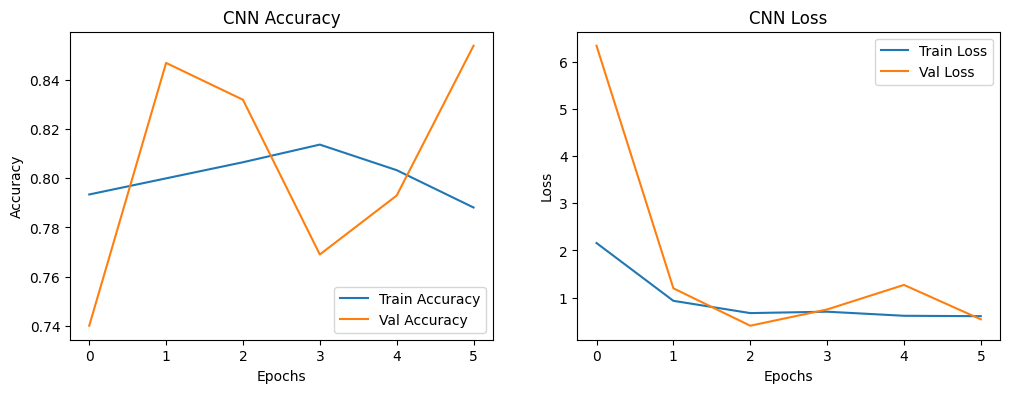

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
=== Classification Report: CNN ===
              precision    recall  f1-score   support

      benign       0.87      0.78      0.82       500
   malignant       0.80      0.89      0.84       500

    accuracy                           0.83      1000
   macro avg       0.84      0.83      0.83      1000
weighted avg       0.84      0.83      0.83      1000



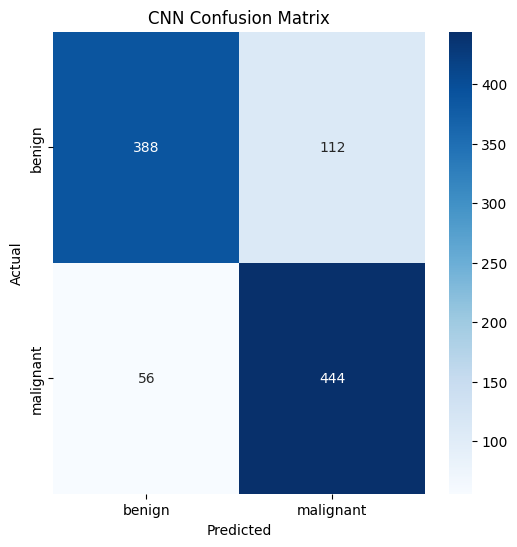

In [12]:
# Build CNN
cnn_model = build_cnn(input_shape, num_classes)
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train CNN with EarlyStopping and Class Weights
history = cnn_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

# Plot training history
plot_history(history, "CNN")

# Evaluate CNN
evaluate_model(cnn_model, test_ds, "CNN")

# Save history
results["CNN"] = history.history


**VGG16**

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 62s 170ms/step - accuracy: 0.7919 - loss: 0.6123 - val_accuracy: 0.9020 - val_loss: 0.2683
Epoch 2/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 47s 154ms/step - accuracy: 0.8725 - loss: 0.2980 - val_accuracy: 0.9120 - val_loss: 0.2330
Epoch 3/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 82s 153ms/step - accuracy: 0.8798 - loss: 0.2802 - val_accuracy: 0.9090 - val_loss: 0.2412
Epoch 4/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 47s 155ms/step - accuracy: 0.8862 - loss: 0.2681 - val_accuracy: 0.9150 - val_loss: 0.2319
Epoch 5/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 46s 152ms/step - accuracy: 0.8932 - loss: 0.2620 - val_accuracy: 0.9060 - val_loss: 0.2540
Epoch 6/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 47s 155ms/step - accuracy: 0.8906 - loss: 0.2607 - val_accuracy: 0.9150 - val_loss: 0.2535
Epoch 7/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 47s 154ms/step - accuracy: 0.8974 - loss: 0.2415 - val_accuracy: 0.9080 - val_loss: 0.2491


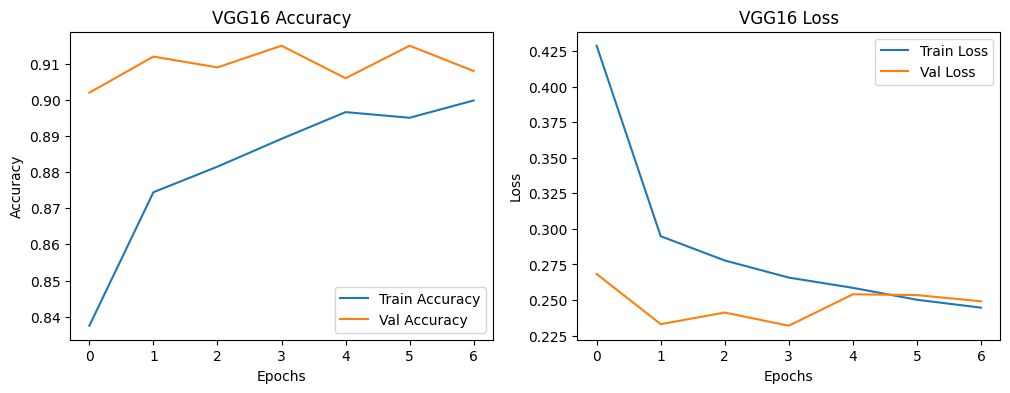

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step
=== Classification Report: VGG16 ===
              precision    recall  f1-score   support

      benign       0.89      0.95      0.92       500
   malignant       0.94      0.88      0.91       500

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.91      1000
weighted avg       0.92      0.92      0.91      1000



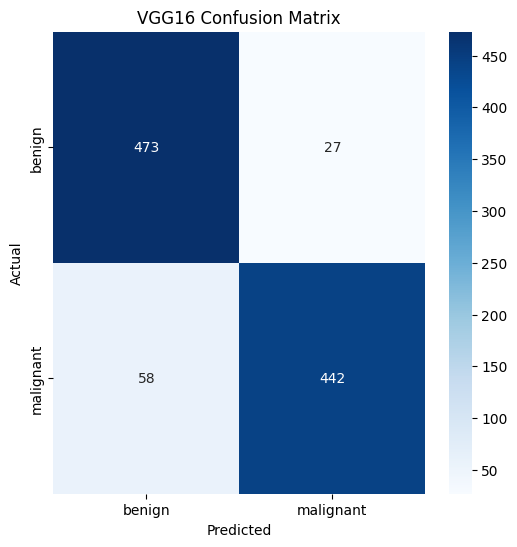

In [13]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping

# Load VGG16 without top layers
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
vgg_base.trainable = False  # Freeze base layers

# Build transfer learning model
vgg_model = models.Sequential([
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile model
vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train model
history = vgg_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

# Plot training history
plot_history(history, "VGG16")

# Evaluate model
evaluate_model(vgg_model, test_ds, "VGG16")

# Save history
results["VGG16"] = history.history


**ResNet50**

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 70s 180ms/step - accuracy: 0.8440 - loss: 0.3820 - val_accuracy: 0.9130 - val_loss: 0.2281
Epoch 2/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 68s 151ms/step - accuracy: 0.9002 - loss: 0.2408 - val_accuracy: 0.9150 - val_loss: 0.2145
Epoch 3/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 46s 151ms/step - accuracy: 0.9052 - loss: 0.2318 - val_accuracy: 0.9140 - val_loss: 0.2072
Epoch 4/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 46s 150ms/step - accuracy: 0.9068 - loss: 0.2252 - val_accuracy: 0.9190 - val_loss: 0.2142
Epoch 5/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 46s 150ms/step - accuracy: 0.9140 - loss: 0.2116 - val_accuracy: 0.9150 - val_loss: 0.2054
Epoch 6/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 82s 152ms/step - accuracy: 0.9127 - loss: 0.2124 - val_accuracy: 0.9120 - val_loss: 0.2032
Epoch 7/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 82s 151ms/step - accuracy: 0.9202 - loss: 0.1937 - val_accuracy: 0.9150 - val_loss: 0.1956
Epoch 8/20
301/301 ━━━━━━━━━━━━━

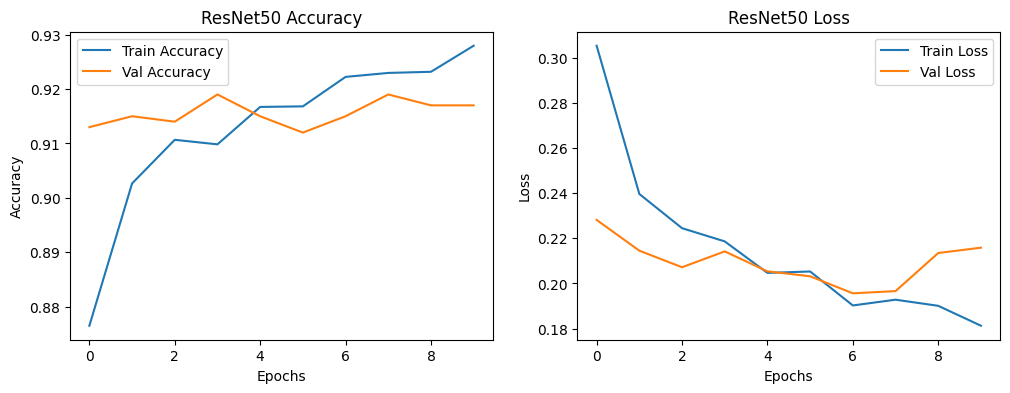

32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step
=== Classification Report: ResNet50 ===
              precision    recall  f1-score   support

      benign       0.88      0.96      0.92       500
   malignant       0.96      0.87      0.91       500

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.91      1000
weighted avg       0.92      0.92      0.91      1000



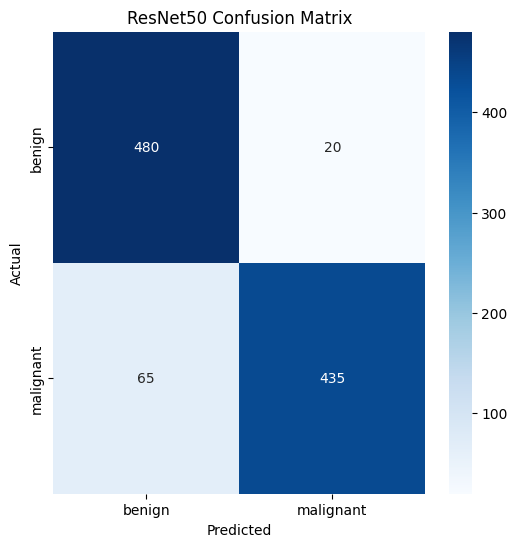

In [14]:
from tensorflow.keras.applications import ResNet50

# Load ResNet50 without top layers
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
resnet_base.trainable = False  # Freeze base layers

# Build transfer learning model
resnet_model = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile model
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model with EarlyStopping and class weights
history = resnet_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

# Plot training history
plot_history(history, "ResNet50")

# Evaluate model
evaluate_model(resnet_model, test_ds, "ResNet50")

# Save history
results["ResNet50"] = history.history


**MobileNetV2**

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 64s 175ms/step - accuracy: 0.7575 - loss: 0.5323 - val_accuracy: 0.7600 - val_loss: 0.4211
Epoch 2/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 45s 147ms/step - accuracy: 0.8126 - loss: 0.4080 - val_accuracy: 0.8470 - val_loss: 0.3363
Epoch 3/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 82s 147ms/step - accuracy: 0.8230 - loss: 0.3921 - val_accuracy: 0.8730 - val_loss: 0.3099
Epoch 4/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 45s 147ms/step - accuracy: 0.8171 - loss: 0.3849 - val_accuracy: 0.8340 - val_loss: 0.3406
Epoch 5/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 45s 147ms/step - accuracy: 0.8309 - loss: 0.3742 - val_accuracy: 0.8720 - val_loss: 0.3038
Epoch 6/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 44s 143ms/step - accuracy: 0.8291 - loss: 0.3745 - val_accuracy: 0.8690 - val_loss: 0.3011
Epoch 7/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 83s 145ms/step - accuracy: 0.8298 - loss: 0.3655 - val_accuracy: 0.8770 - val_loss: 0.2900
Epoch 8/20
301/301 ━━━━━━━━━━━━━━━

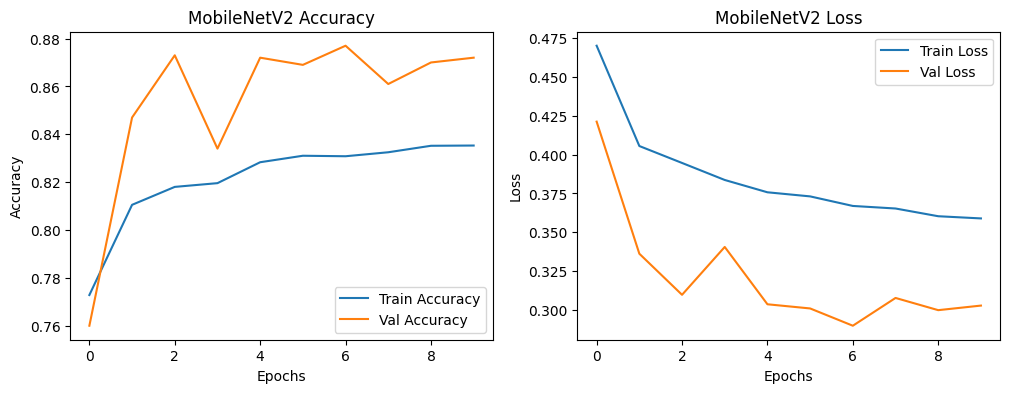

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step
=== Classification Report: MobileNetV2 ===
              precision    recall  f1-score   support

      benign       0.84      0.92      0.88       500
   malignant       0.92      0.83      0.87       500

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



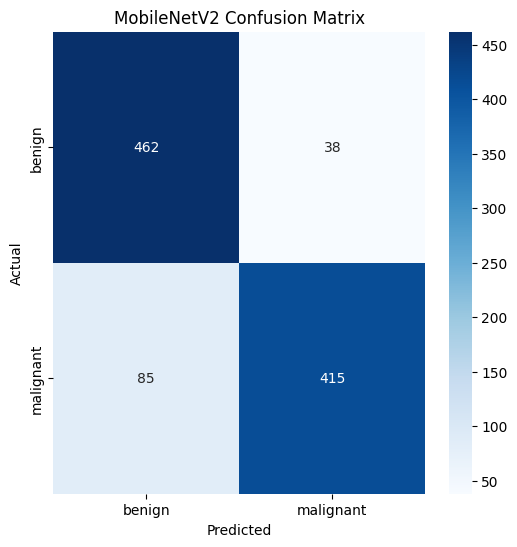

In [15]:
from tensorflow.keras.applications import MobileNetV2

# Load MobileNetV2 without top layers
mobile_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
mobile_base.trainable = False  # Freeze base layers

# Build transfer learning model
mobile_model = models.Sequential([
    mobile_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile model
mobile_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model with EarlyStopping and class weights
history = mobile_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

# Plot training history
plot_history(history, "MobileNetV2")

# Evaluate model
evaluate_model(mobile_model, test_ds, "MobileNetV2")

# Save history
results["MobileNetV2"] = history.history


**InceptionV3**

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 83s 212ms/step - accuracy: 0.7005 - loss: 6.3548 - val_accuracy: 0.7870 - val_loss: 0.4096
Epoch 2/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 46s 152ms/step - accuracy: 0.7431 - loss: 0.4974 - val_accuracy: 0.7790 - val_loss: 0.4356
Epoch 3/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 46s 151ms/step - accuracy: 0.7554 - loss: 0.4812 - val_accuracy: 0.7910 - val_loss: 0.4014
Epoch 4/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 46s 151ms/step - accuracy: 0.7497 - loss: 0.4879 - val_accuracy: 0.7900 - val_loss: 0.4046
Epoch 5/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 46s 151ms/step - accuracy: 0.7584 - loss: 0.4914 - val_accuracy: 0.8040 - val_loss: 0.3901
Epoch 6/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 46s 150ms/step - accuracy: 0.7543 - loss: 0.4913 - val_accuracy: 0.7820 - val_loss: 0.4051
Epoch 7/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 46s 150ms/step - accuracy: 0.7626 - loss: 0.4805 - val_accuracy: 0.8080 - val_loss: 0.3794
Epoch 8/20
301/301 ━━━━━━━━━━━━━

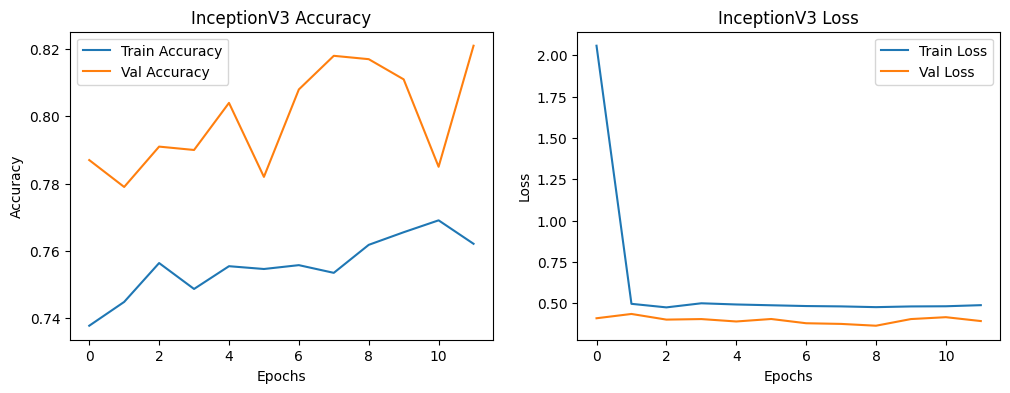

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 239ms/step
=== Classification Report: InceptionV3 ===
              precision    recall  f1-score   support

      benign       0.79      0.86      0.82       500
   malignant       0.85      0.78      0.81       500

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



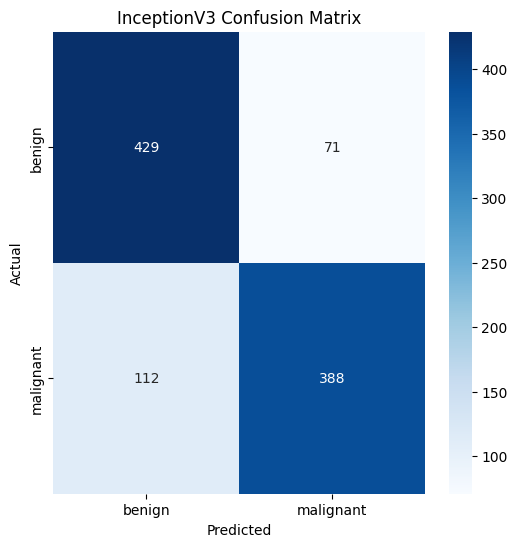

In [17]:
from tensorflow.keras.applications import InceptionV3

# Load InceptionV3 without top layers
inception_base = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
inception_base.trainable = False  # Freeze base layers

# Build transfer learning model
inception_model = models.Sequential([
    inception_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile model
inception_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model with EarlyStopping and class weights
history = inception_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

# Plot training history
plot_history(history, "InceptionV3")

# Evaluate model
evaluate_model(inception_model, test_ds, "InceptionV3")

# Save history
results["InceptionV3"] = history.history
